# Practice 4


**Debugging tip:** When implementing a sorting algorithm, `print()` the state of the list after each step of the outer loop. This lets you verify that elements are moving into the right positions and helps you catch off-by-one errors early.

### Exercise 1: Insertion Sort — Implementation and Empirical Analysis


**Insertion sort** builds a sorted sublist one element at a time. At each step, it takes the next unsorted element and inserts it into its correct position within the already-sorted portion (shifting larger elements to the right).

```
[5, 3, 8, 1]  →  step 1: insert 3 → [3, 5, 8, 1]
                  step 2: insert 8 → [3, 5, 8, 1]  (already in place)
                  step 3: insert 1 → [1, 3, 5, 8]
```

**Tasks:**

1. **Implement** insertion sort as a function `insertion_sort(my_list)` that sorts in place.

2. **Time it** on a list of 100 random floats using `timeit.timeit`. Since the sort modifies the list in place, pass a *copy* each time:
   ```python
   timeit.timeit(lambda: insertion_sort(my_list.copy()), number=1)
   ```

3. **Write a helper function** `time_to_sort(k, f)` that generates a random list of length `k`, sorts it with function `f`, and returns the time taken. This lets you easily sweep across different list sizes.

4. **Measure scaling behavior**: Run your helper for list sizes 10, 100, 1000, 2500, 5000, 10,000, and 100,000. (The largest sizes may take a while — this is expected!)

5. **Plot the results** using `matplotlib.pyplot.scatter`. How does the runtime grow with input size? Does the shape of the curve match insertion sort's theoretical $O(n^2)$ average-case complexity?

In [71]:
import random

def get_random_list(list_len: int, nums_range: list = [1, 100]) -> list[int]:
    return [random.randint(nums_range[0], nums_range[1]) for _ in range(list_len)]

def insertion_sort(ls: list[int]) -> list[int]:
    i = 1
    while i < len(ls):
        j = i
        while j > 0 and ls[j-1] > ls[j]:
            ls[j], ls[j-1] = ls[j-1], ls[j]
            j = j - 1
        i = i + 1

    return ls

In [13]:
import random
import timeit

test_ls = [random.randint(1, 100) for _ in range(random.randint(10,15))]
print(test_ls)
print(insertion_sort(test_ls))

[21, 36, 95, 21, 99, 3, 57, 62, 93, 99, 75]
[3, 21, 21, 36, 57, 62, 75, 93, 95, 99, 99]


In [51]:
def time_to_sort(k: int, f: callable) -> str:
    test_ls = [random.randint(1, 100) for _ in range(k)]
    print(timeit.timeit(lambda: insertion_sort(test_ls.copy()), number=10))

In [50]:
time_to_sort(100, insertion_sort)

0.005337899987353012


Progress: [#################################################>] 100%


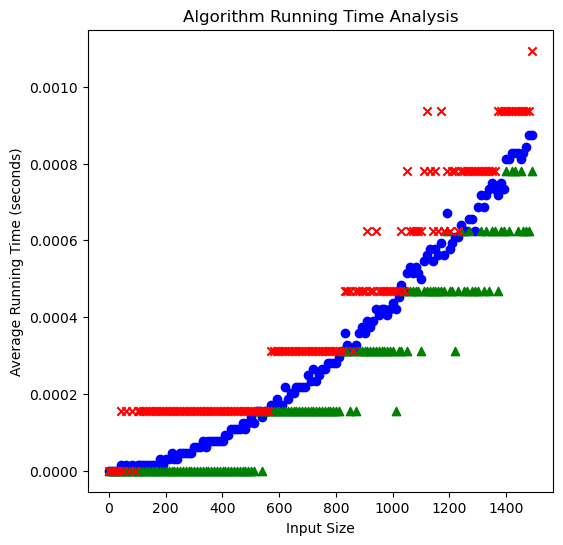

In [26]:
import matplotlib.pyplot as plt
from helper import test_sort_algo


test_sort_algo(insertion_sort)

### Exercise 2: Insertion Sort vs. Python's Built-in Sorting


Compare the performance of three sorting approaches on the **same** randomly generated list:

1. Your `insertion_sort()` from Exercise 1.
2. Python's built-in `sorted()` function (returns a new sorted list).
3. Python's `list.sort()` method (sorts in place).

Use `%timeit` or the `timeit` module for the comparison. Remember to pass `.copy()` so each method works on an unsorted input.

**Questions to consider:**
- How many orders of magnitude faster are the built-in methods?
- `sorted()` and `list.sort()` both use **Timsort** ($O(n \log n)$). Is there a measurable difference between them? Why or why not? *(Hint: one creates a new list, the other sorts in place.)*

In [87]:
test_ls = get_random_list(1000)

print(timeit.timeit(lambda: insertion_sort(test_ls.copy()), number=100))
print(timeit.timeit(lambda: sorted(test_ls.copy()), number=100))
print(timeit.timeit(lambda: test_ls.copy().sort(), number=100))

3.3188985999731813
0.004080799990333617
0.0038389999826904386


### Exercise 3: Sorting with Custom Keys


Generate a list of tuples representing student records in the format `(name, grade, age)`, for example:

```python
students = [
    ("Alice", 85, 19),
    ("Bob", 92, 20),
    ("Charlie", 78, 19),
    ("Diana", 90, 21),
    ...
]
```

Use Python's `sorted()` function with the `key` parameter to sort the students **by age**. If two students have the **same age**, they should be sorted **alphabetically by name** as a tiebreaker.

**Hint:** The `key` function should return a tuple of the sort criteria in priority order. `sorted()` compares tuples element by element, so `key=lambda s: (s[2], s[0])` would sort first by age, then by name.

In [89]:
names = [
    "Elias", 
    "Clara", 
    "Julian", 
    "Isla", 
    "Soren", 
    "Maeve", 
    "Felix", 
    "Nora", 
    "Arlo", 
    "Lyra"
]

students = [(name, random.randint(30,100), random.randint(18, 30)) for name in names]
print(students)
students_sorted = sorted(students, key=lambda students: (students[2], students[0]))
print(students_sorted)

[('Elias', 46, 23), ('Clara', 35, 27), ('Julian', 95, 22), ('Isla', 80, 30), ('Soren', 43, 26), ('Maeve', 59, 27), ('Felix', 99, 18), ('Nora', 72, 30), ('Arlo', 69, 26), ('Lyra', 44, 21)]
[('Felix', 99, 18), ('Lyra', 44, 21), ('Julian', 95, 22), ('Elias', 46, 23), ('Arlo', 69, 26), ('Soren', 43, 26), ('Clara', 35, 27), ('Maeve', 59, 27), ('Isla', 80, 30), ('Nora', 72, 30)]


### Bonus Exercise: Linear Search vs. Binary Search — When Does Sorting Pay Off?


This exercise explores a practical tradeoff: binary search is faster than linear search, but it requires a **sorted** list. When is the upfront cost of sorting worth it?

**Setup:**
- Implement `linear_search(lst, target)` and `binary_search(lst, target)` (binary search assumes a sorted input).
- Generate a list of **1,000,000** random integers between 1 and 100,000,000.

**Experiment:** Repeat the following **100 times** and average the results:
1. Pick a random element from the list using `random.choice()`.
2. Measure the time for **linear search** on the unsorted list.
3. Measure the time for **sort + binary search** (including the sorting step).
4. Measure the time for **binary search alone** (on an already-sorted list, excluding sort time).

**Analysis:**
- On a single lookup, which approach wins?
- The sorting cost is a **one-time** fixed expense. If you need to search the same list $k$ times, at what value of $k$ does the "sort once, then binary search" strategy break even with doing $k$ linear searches? Compute this **break-even point** as: $$k = \frac{T_{\text{sort}}}{T_{\text{linear}} - T_{\text{binary}}}$$
- Try again with a smaller list (e.g., 10,000 elements). How does the break-even point change?

In [68]:
def linear_search(lst: list, target) -> int:
    for i in range(len(lst)):
        if lst[i] == target:
            return i

def binary_search(lst, target) -> int | None:
    left = 0
    right = len(lst) - 1

    while left <= right:
        mid = (left+right)//2

        if lst[mid] == target:
            return mid
        
        if lst[mid] < target:
            left = mid + 1
        else:
            right = mid - 1

    return None


In [96]:
import random
import time

test_list = get_random_list(1000000, [1, 1000000])
print(f"{[test_list[i] for i in range(5)]}...")

target_val = random.choice(test_list)
# print(timeit.timeit(lambda: linear_search(test_list, target_val), number=100))
test_list_sorted = sorted(test_list)
# print(timeit.timeit(lambda: sorted(test_list), number=1))
# print(timeit.timeit(lambda: binary_search(test_list_sorted, target_val), number=100))


time_sum = 0

for _ in range(100):
    target_val = random.choice(test_list)

    time_sum += timeit.timeit(lambda: linear_search(test_list, target_val), number=1)

print(time_sum/100)

time_sum = 0

for _ in range(100):
    target_val = random.choice(test_list)

    time_sum += timeit.timeit(lambda: binary_search(test_list_sorted, target_val), number=1)

print(time_sum/100)

time_sum = 0

for _ in range(100):
    target_val = random.choice(test_list)

    time_sum += timeit.timeit(lambda: sorted(test_list), number=1)
    time_sum += timeit.timeit(lambda: binary_search(test_list_sorted, target_val), number=1)

print(time_sum/100)

[800024, 521989, 88635, 115485, 156604]...
0.013560173001606017
6.821999850217253e-06
0.14538361199985958
